IMPORT OF THE DATA

In [1]:
import pandas as pd

df = pd.read_csv("breast_cancer.data")
df.columns = ['id', 'clump_thickness', 'cell_size', 'cell_shape', 'marginal_adhesion', 
        'epithelial_size', 'bare_nuclei', 'bland_chromatin', 'normal_nucleoli', 
        'mitoses', 'class']

print(df.shape)
print(df.head(10))


(698, 11)
        id  clump_thickness  cell_size  cell_shape  marginal_adhesion  \
0  1002945                5          4           4                  5   
1  1015425                3          1           1                  1   
2  1016277                6          8           8                  1   
3  1017023                4          1           1                  3   
4  1017122                8         10          10                  8   
5  1018099                1          1           1                  1   
6  1018561                2          1           2                  1   
7  1033078                2          1           1                  1   
8  1033078                4          2           1                  1   
9  1035283                1          1           1                  1   

   epithelial_size bare_nuclei  bland_chromatin  normal_nucleoli  mitoses  \
0                7          10                3                2        1   
1                2           2  

In [2]:
print(df.isnull().sum())

id                   0
clump_thickness      0
cell_size            0
cell_shape           0
marginal_adhesion    0
epithelial_size      0
bare_nuclei          0
bland_chromatin      0
normal_nucleoli      0
mitoses              0
class                0
dtype: int64


In [3]:
df = df.drop(columns=['id'])
df['class'] = df['class'].map({2: 0, 4:1})

In [4]:
print(df['clump_thickness'].value_counts())

clump_thickness
1     145
5     129
3     108
4      80
10     69
2      50
8      46
6      34
7      23
9      14
Name: count, dtype: int64


In [5]:
print(df['cell_size'].value_counts())

cell_size
1     383
10     67
3      52
2      45
4      40
5      30
8      29
6      27
7      19
9       6
Name: count, dtype: int64


In [6]:
print(df['bare_nuclei'].value_counts())


bare_nuclei
1     401
10    132
2      30
5      30
3      28
8      21
4      19
?      16
9       9
7       8
6       4
Name: count, dtype: int64


In [7]:
import numpy as np
df = df.replace('?', np.nan)

In [8]:
print(df.isnull().sum())

clump_thickness       0
cell_size             0
cell_shape            0
marginal_adhesion     0
epithelial_size       0
bare_nuclei          16
bland_chromatin       0
normal_nucleoli       0
mitoses               0
class                 0
dtype: int64


In [9]:
print(df.head())

   clump_thickness  cell_size  cell_shape  marginal_adhesion  epithelial_size  \
0                5          4           4                  5                7   
1                3          1           1                  1                2   
2                6          8           8                  1                3   
3                4          1           1                  3                2   
4                8         10          10                  8                7   

  bare_nuclei  bland_chromatin  normal_nucleoli  mitoses  class  
0          10                3                2        1      0  
1           2                3                1        1      0  
2           4                3                7        1      0  
3           1                3                1        1      0  
4          10                9                7        1      1  


In [10]:
from sklearn.model_selection import train_test_split

df_org = df.copy()
X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
fill_value = X_train['bare_nuclei'].mode()[0]
X_train['bare_nuclei'] = X_train['bare_nuclei'].fillna(fill_value)
X_test['bare_nuclei'] = X_test['bare_nuclei'].fillna(fill_value)

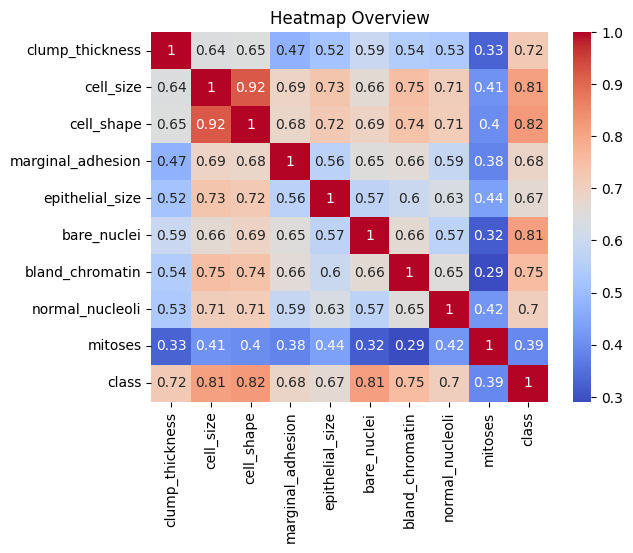

class                1.000000
cell_shape           0.820599
bare_nuclei          0.812119
cell_size            0.811331
bland_chromatin      0.753633
clump_thickness      0.722472
normal_nucleoli      0.704411
marginal_adhesion    0.684294
epithelial_size      0.665581
mitoses              0.392233
Name: class, dtype: float64

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

viz_df = pd.concat([X_train, y_train], axis = 1)

sns.heatmap(viz_df.corr(), annot = True, cmap = 'coolwarm')
plt.title("Heatmap Overview")
plt.show()
viz_df.corr()['class'].sort_values(ascending = False)

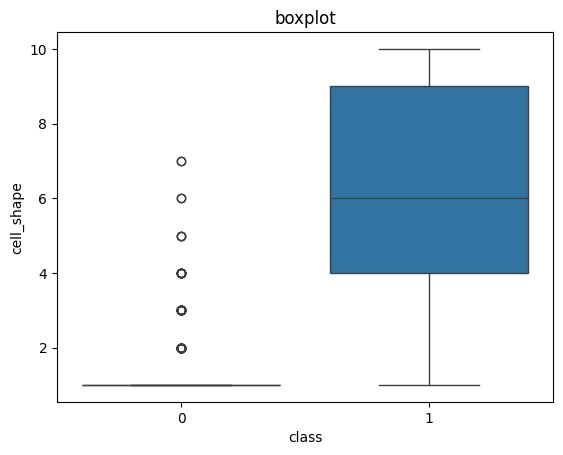

In [22]:
sns.boxplot(x = 'class', y = 'cell_shape', data = viz_df)
plt.title("boxplot")
plt.show()

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_train.columns)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    print(f"{name}: Train: {train_acc}, Test: {test_acc}")

Logistic Regression: Train: 0.967741935483871, Test: 0.9714285714285714
Decision Tree: Train: 1.0, Test: 0.9571428571428572
Random Forest: Train: 1.0, Test: 0.9785714285714285


In [35]:
for name, model in models.items():
    print(name)
    print(classification_report(y_test, model.predict(X_test_scaled)))

Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        89
           1       0.94      0.98      0.96        51

    accuracy                           0.97       140
   macro avg       0.97      0.97      0.97       140
weighted avg       0.97      0.97      0.97       140

Decision Tree
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        89
           1       1.00      0.88      0.94        51

    accuracy                           0.96       140
   macro avg       0.97      0.94      0.95       140
weighted avg       0.96      0.96      0.96       140

Random Forest
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        89
           1       0.94      1.00      0.97        51

    accuracy                           0.98       140
   macro avg       0.97      0.98      0.98       140
weighted avg       0.98   

In [37]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv = 5  )
    print(f"{name}: {scores.mean()} +- {scores.std()}")

Logistic Regression: 0.9623873873873874 +- 0.013118834258672324
Decision Tree: 0.9265122265122265 +- 0.01914148073141849
Random Forest: 0.9623712998712998 +- 0.011923921067659316


RANDOM FOREST IS SELECTED

In [40]:
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2,5]
}

In [42]:
from sklearn.model_selection import GridSearchCV

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    rf_param_grid,
    cv = 5,
    n_jobs= -1, 
    scoring = 'recall' # missing diagonisis is costly mistake
)

rf_grid.fit(X_train_scaled, y_train)
print(rf_grid.best_params_)
print(rf_grid.best_score_)
best_model = rf_grid.best_estimator_
print(best_model.score(X_test_scaled, y_test))

{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
0.9631578947368421
0.9785714285714285


In [43]:
print(classification_report(y_test, best_model.predict(X_test_scaled)))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        89
           1       0.94      1.00      0.97        51

    accuracy                           0.98       140
   macro avg       0.97      0.98      0.98       140
weighted avg       0.98      0.98      0.98       140



In [44]:
import joblib

joblib.dump(best_model, "cancer_model.pkl")

['cancer_model.pkl']

In [ ]:
loaded_model = joblib.load("cancer_model.pkl")
print(loaded_model.score(X_test_scaled, y_test))

0.9785714285714285


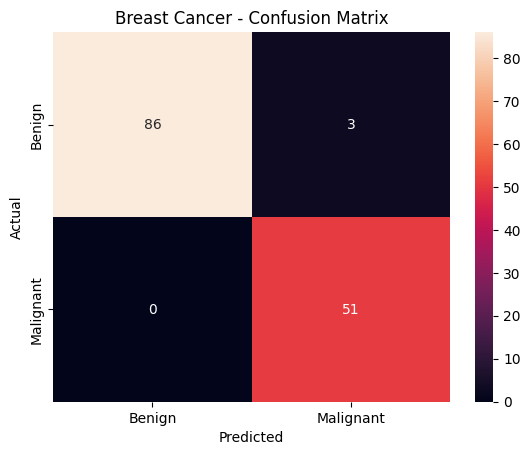

In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, model.predict(X_test_scaled))
sns.heatmap(cm, annot = True, fmt = 'd', xticklabels=['Benign', 'Malignant'], yticklabels= ['Benign', 'Malignant'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Breast Cancer - Confusion Matrix")
plt.show()

Here no patient is missed , only 3 false alarms soo it is working pretty good